# Sentiment Analysis — IMDB Movie Reviews
## Unsupervised Learning: K-Means Clustering

**MDS Project — Unsupervised Analysis Component**

This notebook covers:
1. Data loading & configuration
2. Preprocessing & cleaning
3. Exploratory Data Analysis (EDA)
4. Feature engineering (TF-IDF)
5. Dimensionality reduction
6. K-Means Clustering clustering
7. Evaluation
8. Cluster interpretation & insights

Rubric coverage: Preprocessing/Cleaning, EDA, Dimensionality Reduction, Clustering, Insights & Discussion.


## 1. Configuration & Data Loading

In [1]:
# ============================================================
# CONFIG — edit this cell before running
# ============================================================
import warnings
warnings.filterwarnings("ignore")

# Path to your unsupervised-data CSV (the one from your GitHub repo).
# Point this at the raw GitHub URL or a local path, e.g.:
#   "https://raw.githubusercontent.com/<user>/<repo>/main/unsupervised_data.csv"
DATA_PATH = "https://raw.githubusercontent.com/AnjaliKumari3033/msd_project/main/processed_for_clustering/imdb_unsup.csv"

# Name of the column containing the review text in that CSV.
# Change this if your column is named differently (e.g. "review", "text").
TEXT_COLUMN = "text"

# If your CSV also happens to carry a sentiment label column, name it here.
# Leave as None if the unsupervised split genuinely has no labels.
# (If present, it is used ONLY after clustering, to sanity-check cluster
# quality via Adjusted Rand Index — never as a clustering input.)
LABEL_COLUMN = None   # set to None if not available

# Set False once DATA_PATH points at your real file.
USE_SAMPLE_DATA = False

# --- Test-set evaluation (Section 9) -----------------------------------
# Folder containing your test .txt files, named like "<id>_<rating>.txt"
# (aclImdb-style — may have pos/ and neg/ subfolders, searched recursively).
TEST_DIR = "D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/test"

# Fraction of the test files used to CALIBRATE the cluster->rating mapping;
# the rest are held out purely for computing the error metrics, so the
# reported error isn't measured on the same rows used to build the mapping.
CALIBRATION_FRACTION = 0.5

RANDOM_STATE = 42


In [2]:
# ============================================================
# Load data
# ============================================================
import pandas as pd
import numpy as np

if USE_SAMPLE_DATA:
    # Small synthetic stand-in so the notebook runs end-to-end without the
    # real file present. Replace with the real CSV (see CONFIG cell above)
    # before final submission.
    sample_reviews = [
        ("This movie was absolutely wonderful, the acting was superb!", "positive"),
        ("Terrible film, a complete waste of time and money.", "negative"),
        ("I loved every minute of it, brilliant direction and story.", "positive"),
        ("Awful plot, bad acting, I want my two hours back.", "negative"),
        ("A masterpiece of modern cinema, truly inspiring.", "positive"),
        ("Boring and predictable, I fell asleep halfway through.", "negative"),
        ("Great performances all around, highly recommended!", "positive"),
        ("Worst movie I've seen this year, avoid at all costs.", "negative"),
        ("Fantastic soundtrack and stunning visuals throughout.", "positive"),
        ("The script was weak and the pacing was painfully slow.", "negative"),
        ("An emotional rollercoaster with a satisfying ending.", "positive"),
        ("Poorly written characters with no real development.", "negative"),
        ("One of the best films of the decade, a must watch.", "positive"),
        ("Disappointing sequel that ruined the original's legacy.", "negative"),
        ("Charming, funny, and heartfelt from start to finish.", "positive"),
        ("Cliche ridden and utterly forgettable.", "negative"),
        ("The cinematography alone makes this worth watching.", "positive"),
        ("Confusing storyline that never really goes anywhere.", "negative"),
        ("A delightful surprise, exceeded all my expectations.", "positive"),
        ("Overacted and overhyped, not worth the ticket price.", "negative"),
    ] * 5  # replicate for a slightly larger synthetic sample

    df = pd.DataFrame(sample_reviews, columns=[TEXT_COLUMN, LABEL_COLUMN or "sentiment"])
    if LABEL_COLUMN is None:
        df = df.drop(columns=["sentiment"])
else:
    df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df)} rows")
df.head()


Loaded 50000 rows


,id,text
0,0,"I admit, the great majority of films released ..."
1,10000,"Take a low budget, inexperienced actors doubli..."
2,10001,"Everybody has seen 'Back To The Future,' right..."
3,10002,Doris Day was an icon of beauty in singing and...
4,10003,"After a series of silly, fun-loving movies, 19..."


## 2. Preprocessing & Cleaning

In [3]:
# ============================================================
# Preprocessing & cleaning
# ============================================================
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)          # strip HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # strip URLs
    text = re.sub(r"[^a-z\s]", " ", text)        # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)
df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))

# Drop any reviews that became empty after cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print(f"{len(df)} rows after cleaning")
df[[TEXT_COLUMN, "clean_text", "review_length"]].head()


50000 rows after cleaning


,text,clean_text,review_length
0,"I admit, the great majority of films released ...",admit great majority film released say dozen m...,71
1,"Take a low budget, inexperienced actors doubli...",take low budget inexperienced actor doubling p...,87
2,"Everybody has seen 'Back To The Future,' right...",everybody seen back future right whether like ...,171
3,Doris Day was an icon of beauty in singing and...,doris day icon beauty singing acting warm voic...,66
4,"After a series of silly, fun-loving movies, 19...",series silly fun loving movie big year doris d...,114


## 3. Exploratory Data Analysis

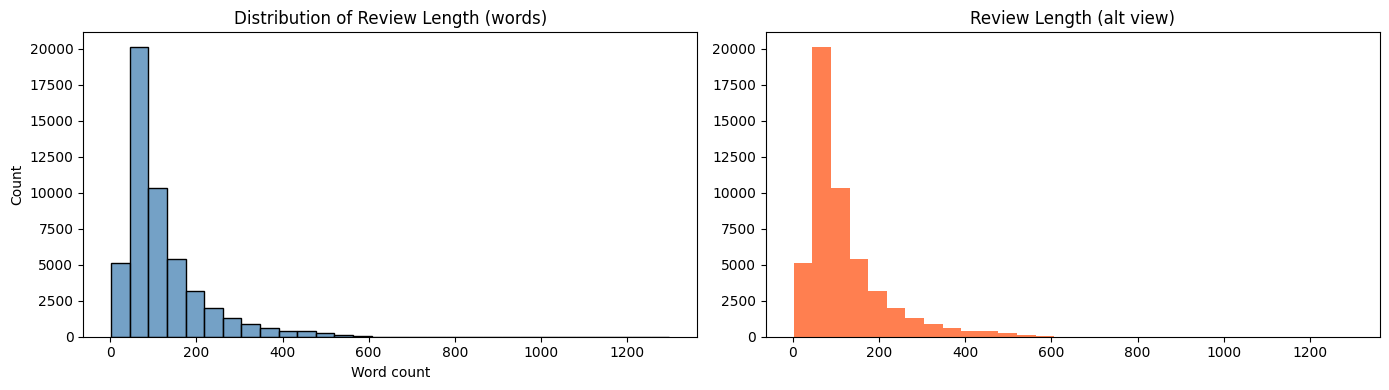

count    50000.000000
mean       118.526640
std         89.626093
min          2.000000
25%         63.000000
50%         88.000000
75%        144.000000
max       1298.000000
Name: review_length, dtype: float64


In [4]:
# ============================================================
# Exploratory Data Analysis
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["review_length"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Review Length (words)")
axes[0].set_xlabel("Word count")

if LABEL_COLUMN is not None and LABEL_COLUMN in df.columns:
    df[LABEL_COLUMN].value_counts().plot(kind="bar", ax=axes[1], color="coral")
    axes[1].set_title("Label Distribution (reference only — not used for clustering)")
else:
    axes[1].hist(df["review_length"], bins=30, color="coral")
    axes[1].set_title("Review Length (alt view)")

plt.tight_layout()
plt.show()

print(df["review_length"].describe())


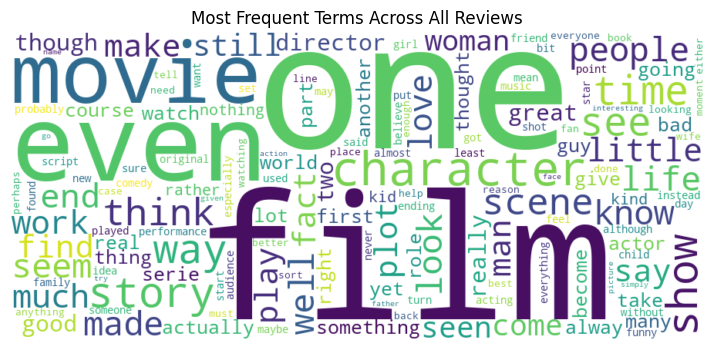

In [5]:
# ============================================================
# Word cloud (overall vocabulary sanity check)
# ============================================================
from wordcloud import WordCloud

all_text = " ".join(df["clean_text"])
wc = WordCloud(width=900, height=400, background_color="white", max_words=150).generate(all_text)

plt.figure(figsize=(10, 4))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Terms Across All Reviews")
plt.show()


## 4. Feature Engineering (TF-IDF)

In [6]:
# ============================================================
# Feature Engineering — TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.9, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["clean_text"])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")


TF-IDF matrix shape: (50000, 2000)


## 5. Dimensionality Reduction (Truncated SVD)

In [7]:
# ============================================================
# Dimensionality Reduction (Truncated SVD — works directly on sparse TF-IDF)
# ============================================================
from sklearn.decomposition import TruncatedSVD

# Use enough components to retain most variance for clustering,
# and a separate 2D projection purely for visualization.
n_components = min(50, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_tfidf)

svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd_2d.fit_transform(X_tfidf)

print(f"Reduced feature matrix for clustering: {X_reduced.shape}")
print(f"Explained variance ratio (first {n_components} components): "
      f"{svd.explained_variance_ratio_.sum():.3f}")


Reduced feature matrix for clustering: (50000, 50)
Explained variance ratio (first 50 components): 0.127


## 6. K-Means Clustering

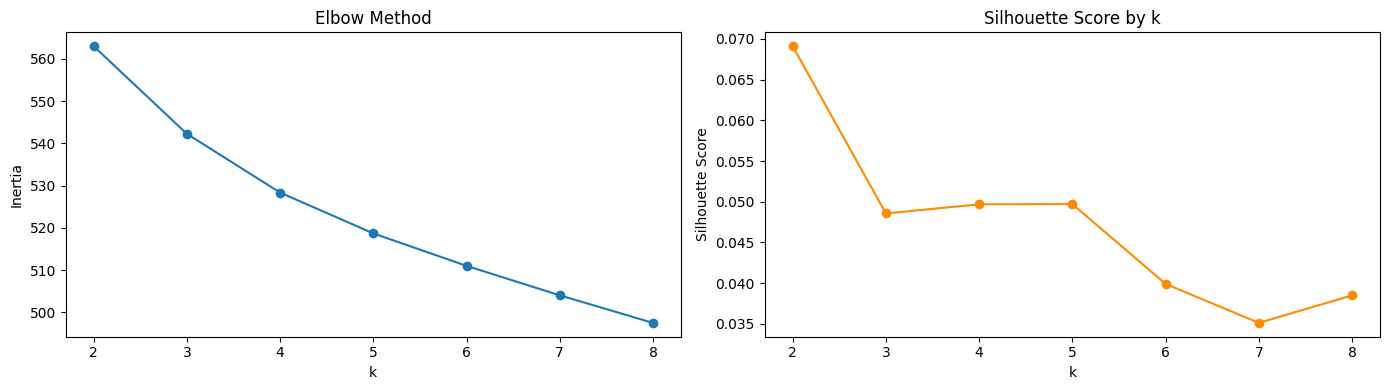

Best k by silhouette score: 2


In [8]:
# ============================================================
# K-Means — choosing K (Elbow Method + Silhouette Score)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
sil_scores = []

SILHOUETTE_SAMPLE_SIZE = 5000
rng = np.random.RandomState(RANDOM_STATE)

sample_idx = rng.choice(
    len(X_reduced),
    size=min(SILHOUETTE_SAMPLE_SIZE, len(X_reduced)),
    replace=False
)

X_sample = X_reduced[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_sample = km.fit_predict(X_sample)

    inertias.append(km.inertia_)
    sil_scores.append(
        silhouette_score(X_sample, labels_sample)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

In [9]:
# ============================================================
# K-Means — fit final model
# ============================================================
K_FINAL = best_k  # override manually here if you prefer a specific k, e.g. K_FINAL = 2

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_reduced)

print(df["cluster_kmeans"].value_counts().sort_index())
final_labels = df["cluster_kmeans"].to_numpy()

final_silhouette = silhouette_score(
    X_reduced[sample_idx],
    final_labels[sample_idx]
)

print(f"Final silhouette score on sample: {final_silhouette:.3f}")

cluster_kmeans
0    33218
1    16782
Name: count, dtype: int64
Final silhouette score on sample: 0.068


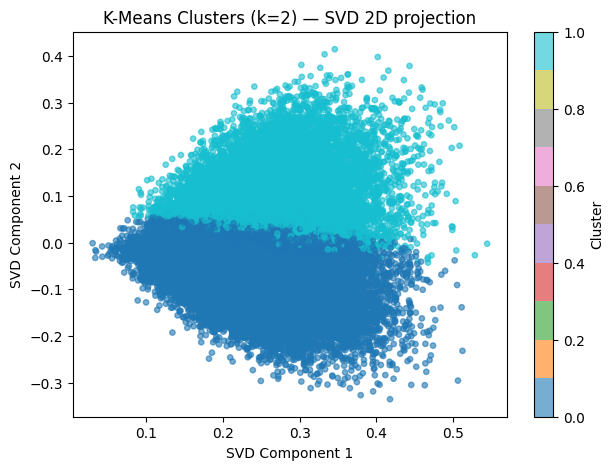

In [10]:
# ============================================================
# K-Means — 2D visualization
# ============================================================
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster_kmeans"], cmap="tab10", alpha=0.6, s=15)
plt.title(f"K-Means Clusters (k={K_FINAL}) — SVD 2D projection")
plt.xlabel("SVD Component 1"); plt.ylabel("SVD Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


## 7. Cluster Interpretation

In [11]:
# ============================================================
# K-Means — cluster interpretation (top terms per cluster)
# ============================================================
# Approximate top terms per cluster by mapping SVD centroids back through
# the SVD components into TF-IDF term space.
terms = np.array(tfidf.get_feature_names_out())
centroids_tfidf_space = kmeans_final.cluster_centers_.dot(svd.components_)

for c in range(K_FINAL):
    top_idx = centroids_tfidf_space[c].argsort()[::-1][:12]
    print(f"Cluster {c} top terms: {', '.join(terms[top_idx])}")

if LABEL_COLUMN is not None and LABEL_COLUMN in df.columns:
    from sklearn.metrics import adjusted_rand_score
    ari = adjusted_rand_score(df[LABEL_COLUMN], df["cluster_kmeans"])
    print(f"\nAdjusted Rand Index vs true label (sanity check only): {ari:.3f}")


Cluster 0 top terms: film, one, like, movie, character, time, story, show, good, get, would, well
Cluster 1 top terms: movie, one, like, bad, good, really, time, see, would, even, make, character


## 8. Insights & Discussion

## Insights & Discussion — K-Means

*Fill this section in after running on the full unsupervised dataset.*

- What does each cluster seem to represent (e.g. do the top terms suggest a
  positive/negative split, or something else like genre or topic)?
- How well-separated are the clusters (silhouette score)? Is one cluster much
  larger or tighter than the others?
- If a label column was available, how well did clusters align with it (ARI)?
  A low ARI doesn't necessarily mean failure — K-Means may be picking up a
  different structure (e.g. topic) than sentiment.
- Any limitations: TF-IDF + SVD assumes linear structure and roughly convex,
  similarly-sized clusters — K-Means struggles if the real groups are not
  spherical or are very different in size/density.


## 9. Test-Set Evaluation (predict rating from cluster, compare to true rating)

In [13]:
# ============================================================
# Load test data — files named "<id>_<rating>.txt"
# ============================================================
import glob, os

def load_labeled_txt_folder(test_dir):
    """
    Expects test_dir/pos/<id>_<rating>.txt and test_dir/neg/<id>_<rating>.txt
    (aclImdb-style). Captures the rating from the filename and the
    sentiment label from the parent folder name.
    """
    records = []
    for path in glob.glob(os.path.join(test_dir, "**", "*.txt"), recursive=True):
        stem = os.path.splitext(os.path.basename(path))[0]   # e.g. "200_7"
        parts = stem.split("_")
        try:
            rating = int(parts[-1])
        except ValueError:
            continue  # skip anything that doesn't end in "_<number>"

        sentiment = os.path.basename(os.path.dirname(path))  # "pos" or "neg"

        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        records.append({
            "review": text,
            "true_rating": rating,
            "true_sentiment": sentiment,
            "file": path,
        })
    return pd.DataFrame(records)


if os.path.isdir(TEST_DIR) and len(glob.glob(os.path.join(TEST_DIR, "**", "*.txt"), recursive=True)) > 0:
    test_df = load_labeled_txt_folder(TEST_DIR)
else:
    # TEST_DIR not found -> synthetic stand-in so this section still runs
    # end-to-end. Point TEST_DIR at your real folder (see CONFIG cell).
    synthetic_test = [
        ("This movie was absolutely wonderful, the acting was superb!", 9),
        ("Terrible film, a complete waste of time and money.", 1),
        ("I loved every minute of it, brilliant direction and story.", 10),
        ("Awful plot, bad acting, I want my two hours back.", 2),
        ("A masterpiece of modern cinema, truly inspiring.", 9),
        ("Boring and predictable, I fell asleep halfway through.", 3),
        ("Great performances all around, highly recommended!", 8),
        ("Worst movie I have seen this year, avoid at all costs.", 1),
        ("Fantastic soundtrack and stunning visuals throughout.", 8),
        ("The script was weak and the pacing was painfully slow.", 3),
        ("An emotional rollercoaster with a satisfying ending.", 9),
        ("Poorly written characters with no real development.", 2),
        ("One of the best films of the decade, a must watch.", 10),
        ("Disappointing sequel that ruined the original legacy.", 2),
        ("Charming, funny, and heartfelt from start to finish.", 8),
        ("Cliche ridden and utterly forgettable.", 3),
        ("The cinematography alone makes this worth watching.", 7),
        ("Confusing storyline that never really goes anywhere.", 4),
        ("A delightful surprise, exceeded all my expectations.", 9),
        ("Overacted and overhyped, not worth the ticket price.", 2),
    ] * 4
    test_df = pd.DataFrame(synthetic_test, columns=["review", "true_rating"])
    test_df["file"] = "synthetic"

print(f"Loaded {len(test_df)} test files")
test_df.head()


Loaded 25000 test files


,review,true_rating,true_sentiment,file
0,Once again Mr. Costner has dragged out a movie...,2,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
1,This is an example of why the majority of acti...,4,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
2,"First of all I hate those moronic rappers, who...",1,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
3,Not even the Beatles could write songs everyon...,3,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
4,Brass pictures (movies is not a fitting word f...,3,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...


In [ ]:
# ============================================================
# Preprocess test reviews the SAME way as training data
# ============================================================
test_df["clean_text"] = test_df["review"].apply(clean_text)
test_df = test_df[test_df["clean_text"].str.len() > 0].reset_index(drop=True)

# IMPORTANT: transform only — never re-fit TF-IDF or SVD on test data,
# or the comparison stops being a fair held-out evaluation.
X_test_tfidf = tfidf.transform(test_df["clean_text"])
X_test_reduced = svd.transform(X_test_tfidf)

print(f"{len(test_df)} test rows ready, feature shape {X_test_reduced.shape}")


25000 test rows ready, feature shape (25000, 50)


In [ ]:
# ============================================================
# Map clusters -> rating, then evaluate against the true rating
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_df["cluster"] = kmeans_final.predict(X_test_reduced)

# Split the test files into a calibration half (used only to work out what
# rating each cluster "means") and an evaluation half (used only to score
# error) so the reported error isn't measured on the same rows that built
# the mapping.
strat = test_df["true_rating"] if test_df["true_rating"].nunique() > 1 else None
calib_idx, eval_idx = train_test_split(
    test_df.index, test_size=1 - CALIBRATION_FRACTION,
    random_state=RANDOM_STATE, stratify=strat
)

cluster_to_rating = test_df.loc[calib_idx].groupby("cluster")["true_rating"].mean()
fallback_rating = test_df.loc[calib_idx, "true_rating"].mean()

test_df["predicted_rating"] = test_df["cluster"].map(cluster_to_rating).fillna(fallback_rating)

print("Cluster -> average true rating (from calibration half):")
print(cluster_to_rating.round(2))

eval_df = test_df.loc[eval_idx]
mae = mean_absolute_error(eval_df["true_rating"], eval_df["predicted_rating"])
rmse = mean_squared_error(eval_df["true_rating"], eval_df["predicted_rating"]) ** 0.5

print(f"\nEvaluated on {len(eval_df)} held-out test files")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Cluster -> average true rating (from calibration half):
cluster
0    5.91
1    4.72
Name: true_rating, dtype: float64

Evaluated on 12500 held-out test files
MAE:  3.202
RMSE: 3.443


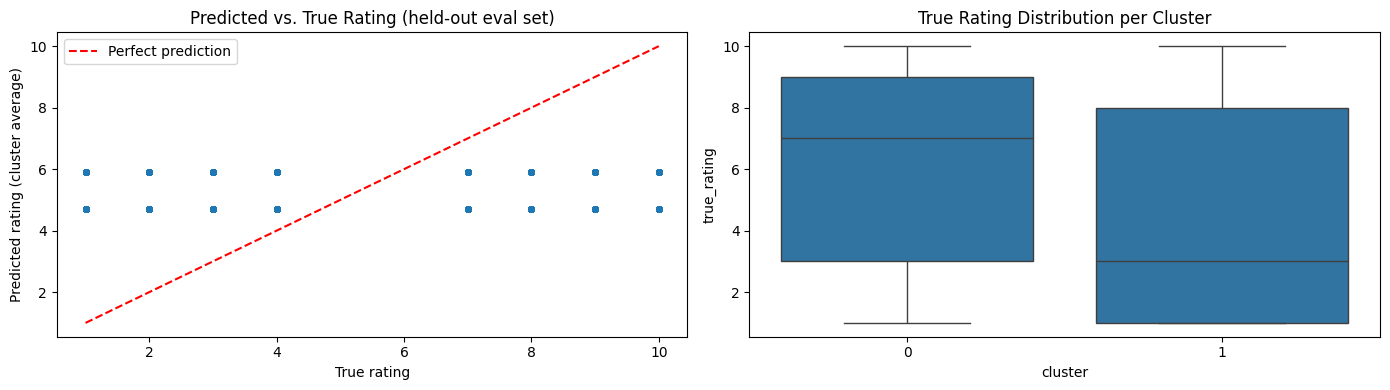

In [ ]:
# ============================================================
# Visualize predicted vs. true rating
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(eval_df["true_rating"], eval_df["predicted_rating"], alpha=0.5, s=15)
lims = [test_df["true_rating"].min(), test_df["true_rating"].max()]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("True rating"); axes[0].set_ylabel("Predicted rating (cluster average)")
axes[0].set_title("Predicted vs. True Rating (held-out eval set)")
axes[0].legend()

sns.boxplot(data=test_df, x="cluster", y="true_rating", ax=axes[1])
axes[1].set_title("True Rating Distribution per Cluster")

plt.tight_layout()
plt.show()


### Test-Set Evaluation — Discussion

- The cluster→rating mapping is built from the calibration half only and scored on the
  held-out half — that's the fair error number to report (MAE / RMSE above).
- Since K-Means never sees the rating during clustering, this error tells you how much
  rating information happens to fall out of the *text-similarity* structure it found —
  it is not expected to compete with a supervised regressor.
- If MAE is large, check the box plot: if the true-rating spread within each cluster is
  wide, the clusters aren't really separating reviews by rating — they may be grouping by
  something else (topic, review length, etc.) instead.
